In [1]:
# ============================================================
# MEDICAL INSURANCE COST PREDICTION — SVR IMPLEMENTATION
# Complete Optimized Version for Google Colab
# ============================================================

# ──────────────────────────────────────────────────────────
# CELL 1: Mount Drive & Load Dataset
# ──────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── CHANGE THIS PATH to your actual CSV location in Drive ──
df = pd.read_csv("/content/drive/MyDrive/medical_insurance.csv")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Full dataset shape: {df.shape}")
df.head()

Mounted at /content/drive
Full dataset shape: (100000, 54)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,48299,60,Male,East,Urban,30600.0,Masters,Single,Employed,4,...,0,0,1,1,0,1,0,1,1,1
1,81048,40,Male,North,Rural,55900.0,Some College,Married,Employed,2,...,0,0,0,0,0,0,1,0,0,0
2,92755,55,Male,East,Urban,226200.0,HS,Married,Employed,3,...,0,0,0,0,0,1,0,0,1,0
3,46008,40,Female,Central,Suburban,70700.0,Some College,Married,Employed,3,...,0,1,0,1,0,0,1,0,0,0
4,76982,70,Male,West,Urban,107200.0,No HS,Single,Employed,2,...,0,1,0,0,0,0,1,1,1,0


In [2]:
# ──────────────────────────────────────────────────────────
# CELL 2: Sample 15,000 rows (SVR optimization)
# ──────────────────────────────────────────────────────────

df = df.sample(n=15000, random_state=42).reset_index(drop=True)
print(f"Working dataset shape after sampling: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())

Working dataset shape after sampling: (15000, 54)

Column names:
['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


In [3]:
# ──────────────────────────────────────────────────────────
# CELL 3: Exploratory Data Analysis
# ──────────────────────────────────────────────────────────

print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\n=== Target Variable Stats ===")
print(df['annual_medical_cost'].describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 54 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_id                    15000 non-null  int64  
 1   age                          15000 non-null  int64  
 2   sex                          15000 non-null  object 
 3   region                       15000 non-null  object 
 4   urban_rural                  15000 non-null  object 
 5   income                       15000 non-null  float64
 6   education                    15000 non-null  object 
 7   marital_status               15000 non-null  object 
 8   employment_status            15000 non-null  object 
 9   household_size               15000 non-null  int64  
 10  dependents                   15000 non-null  int64  
 11  bmi                          15000 non-null  float64
 12  smoker                       15000 non-null  object 


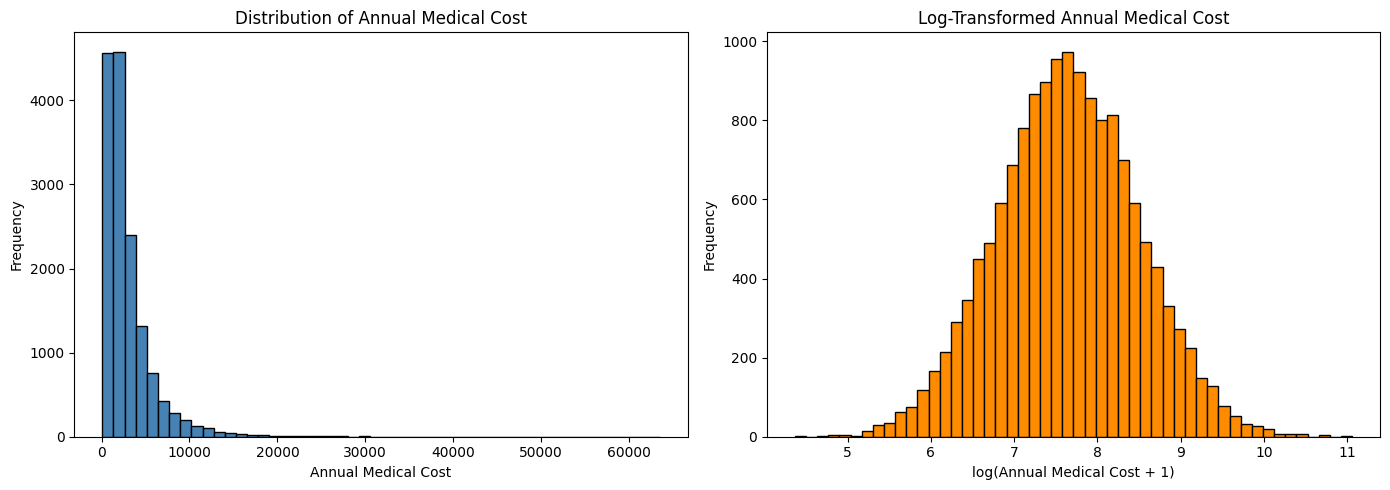

Saved: svr_target_distribution.png

=== Top 20 Correlations with Target ===
annual_medical_cost            1.000000
annual_premium                 0.968497
monthly_premium                0.968497
total_claims_paid              0.752394
avg_claim_amount               0.634800
risk_score                     0.315810
chronic_count                  0.308945
is_high_risk                   0.260553
days_hospitalized_last_3yrs    0.225934
visits_last_year               0.207864
hospitalizations_last_3yrs     0.202170
claims_count                   0.198734
hypertension                   0.148468
mental_health                  0.145288
systolic_bp                    0.142868
age                            0.140447
had_major_procedure            0.131700
diastolic_bp                   0.116990
medication_count               0.113229
diabetes                       0.110906
Name: annual_medical_cost, dtype: float64


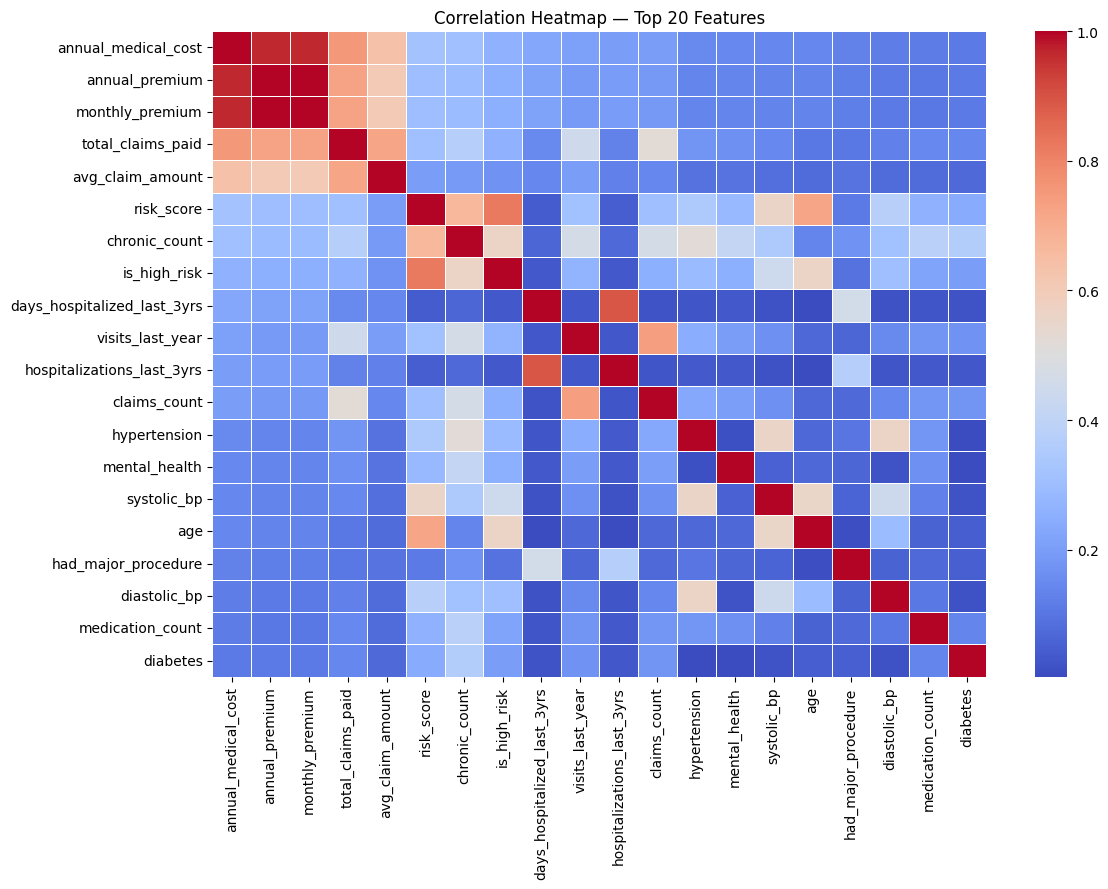

Saved: svr_correlation_heatmap.png


In [4]:
# ──────────────────────────────────────────────────────────
# CELL 4: EDA Visualizations
# ──────────────────────────────────────────────────────────

# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['annual_medical_cost'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Annual Medical Cost')
axes[0].set_xlabel('Annual Medical Cost')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['annual_medical_cost']), bins=50, color='darkorange', edgecolor='black')
axes[1].set_title('Log-Transformed Annual Medical Cost')
axes[1].set_xlabel('log(Annual Medical Cost + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svr_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: svr_target_distribution.png")

# Top correlations with target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df[numeric_cols].corr()['annual_medical_cost'].sort_values(ascending=False)
print("\n=== Top 20 Correlations with Target ===")
print(corr_with_target.head(20))

# Correlation heatmap (top 20 features)
top_features = corr_with_target.abs().nlargest(20).index
plt.figure(figsize=(12, 9))
sns.heatmap(df[top_features].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Top 20 Features')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svr_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: svr_correlation_heatmap.png")

In [5]:
# ──────────────────────────────────────────────────────────
# CELL 5: Preprocessing
# ──────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

df_processed = df.copy()

# Drop identifier column
if 'person_id' in df_processed.columns:
    df_processed.drop(columns=['person_id'], inplace=True)

# Fill missing values
for col in df_processed.columns:
    if df_processed[col].dtype == 'object':
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
    else:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

# Encode categorical columns
le = LabelEncoder()
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Encoding {len(categorical_cols)} categorical columns: {categorical_cols}")

for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

# Separate features and target
TARGET = 'annual_medical_cost'
X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape:         {y.shape}")
print(f"Target range:         {y.min():,.0f} — {y.max():,.0f}")

Encoding 10 categorical columns: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']

Feature matrix shape: (15000, 52)
Target shape:         (15000,)
Target range:         78 — 63,482


In [6]:
# ──────────────────────────────────────────────────────────
# CELL 6: Train / Validation / Test Split (70 / 10 / 20)
# ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# Step 1: Split off 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Step 2: From remaining 80%, take 12.5% as validation → gives 10% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42
)

total = len(X)
print(f"Total samples:      {total}")
print(f"Training set:       {len(X_train):,}  ({len(X_train)/total*100:.1f}%)")
print(f"Validation set:     {len(X_val):,}   ({len(X_val)/total*100:.1f}%)")
print(f"Test set:           {len(X_test):,}  ({len(X_test)/total*100:.1f}%)")

Total samples:      15000
Training set:       10,500  (70.0%)
Validation set:     1,500   (10.0%)
Test set:           3,000  (20.0%)


In [7]:
# ──────────────────────────────────────────────────────────
# CELL 7: Feature Selection & Scaling
# ──────────────────────────────────────────────────────────

# Select top 30 features using f_regression (fit on training data ONLY)
K = 30
selector = SelectKBest(score_func=f_regression, k=K)
selector.fit(X_train, y_train)

selected_features = X.columns[selector.get_support()].tolist()
print(f"Selected {K} features:\n{selected_features}")

X_train_sel = selector.transform(X_train)
X_val_sel   = selector.transform(X_val)
X_test_sel  = selector.transform(X_test)

# Standard scaling — CRITICAL for SVR performance
# Fit scaler on training data ONLY, then transform all splits
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_sel)
X_val_scaled   = scaler_X.transform(X_val_sel)
X_test_scaled  = scaler_X.transform(X_test_sel)

# Scale target too — helps SVR with large value ranges
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()

print("\nScaling complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")

Selected 30 features:
['age', 'smoker', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'hba1c', 'risk_score', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Scaling complete.
X_train_scaled shape: (10500, 30)


In [8]:
# ──────────────────────────────────────────────────────────
# CELL 8: SVR Model Training (Initial)
# ──────────────────────────────────────────────────────────
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Initial hyperparameter settings
svr_params = {
    'kernel':     'rbf',
    'C':          100,
    'epsilon':    0.1,
    'gamma':      'scale',
    'cache_size': 2000
}

print("=== SVR Hyperparameter Settings ===")
for k, v in svr_params.items():
    print(f"  {k}: {v}")

svr_model = SVR(**svr_params)

print(f"\nTraining SVR on {len(X_train_scaled):,} samples...")
start_time = time.time()
svr_model.fit(X_train_scaled, y_train_scaled)
train_time = time.time() - start_time

print(f"✅ Training completed in {train_time:.2f} seconds ({train_time/60:.1f} min)")
print(f"   Number of support vectors: {svr_model.n_support_[0]:,}")

# ── CHECKPOINT: Save immediately after training ──
import joblib
joblib.dump(svr_model, '/content/drive/MyDrive/svr_checkpoint_model.pkl')
joblib.dump(scaler_X,  '/content/drive/MyDrive/svr_checkpoint_scaler_X.pkl')
joblib.dump(scaler_y,  '/content/drive/MyDrive/svr_checkpoint_scaler_y.pkl')
joblib.dump(selector,  '/content/drive/MyDrive/svr_checkpoint_selector.pkl')
print("✅ Checkpoint saved to Drive")

=== SVR Hyperparameter Settings ===
  kernel: rbf
  C: 100
  epsilon: 0.1
  gamma: scale
  cache_size: 2000

Training SVR on 10,500 samples...
✅ Training completed in 118.66 seconds (2.0 min)
   Number of support vectors: 5,531
✅ Checkpoint saved to Drive


In [9]:
# ──────────────────────────────────────────────────────────
# CELL 9: Evaluation Helper Function
# ──────────────────────────────────────────────────────────

def evaluate_model(model, X_scaled, y_true_original, scaler_y, label=""):
    y_pred_scaled = model.predict(X_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    mae  = mean_absolute_error(y_true_original, y_pred)
    mse  = mean_squared_error(y_true_original, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true_original, y_pred)
    mape = np.mean(np.abs((y_true_original - y_pred) / (y_true_original + 1e-8))) * 100

    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  MAE:   {mae:>15,.2f}")
    print(f"  MSE:   {mse:>15,.2f}")
    print(f"  RMSE:  {rmse:>15,.2f}")
    print(f"  R²:    {r2:>15.4f}")
    print(f"  MAPE:  {mape:>14.2f}%")

    return y_pred, {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


def plot_results(y_true, y_pred, metrics, title_prefix, save_prefix):
    residuals = y_true - y_pred
    pct_error = np.abs(residuals / (y_true + 1e-8)) * 100

    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(2, 3, figure=fig)

    # 1. Actual vs Predicted
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_true, y_pred, alpha=0.3, s=5, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax1.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
    ax1.set_xlabel('Actual Cost')
    ax1.set_ylabel('Predicted Cost')
    ax1.set_title(f'{title_prefix}: Actual vs Predicted')
    ax1.legend()

    # 2. Residuals vs Predicted
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.scatter(y_pred, residuals, alpha=0.3, s=5, color='darkorange')
    ax2.axhline(0, color='red', linestyle='--', linewidth=2)
    ax2.set_xlabel('Predicted Cost')
    ax2.set_ylabel('Residuals')
    ax2.set_title(f'{title_prefix}: Residuals vs Predicted')

    # 3. Residual Distribution
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(residuals, bins=50, color='green', edgecolor='black', alpha=0.7)
    ax3.axvline(0, color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Residual Value')
    ax3.set_ylabel('Frequency')
    ax3.set_title(f'{title_prefix}: Residual Distribution')

    # 4. MAE & RMSE bar chart
    ax4 = fig.add_subplot(gs[1, 0])
    bars = ax4.bar(['MAE', 'RMSE'],
                   [metrics['MAE'], metrics['RMSE']],
                   color=['steelblue', 'darkorange'], edgecolor='black')
    for bar, val in zip(bars, [metrics['MAE'], metrics['RMSE']]):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.95,
                 f'{val:,.0f}', ha='center', va='top',
                 color='white', fontweight='bold')
    ax4.set_title(f'{title_prefix}: MAE & RMSE')
    ax4.set_ylabel('Value')

    # 5. Metrics summary box
    ax5 = fig.add_subplot(gs[1, 1])
    info_text = (
        f"R² Score :  {metrics['R2']:.4f}\n"
        f"MAE      :  {metrics['MAE']:,.2f}\n"
        f"MSE      :  {metrics['MSE']:,.2f}\n"
        f"RMSE     :  {metrics['RMSE']:,.2f}\n"
        f"MAPE     :  {metrics['MAPE']:.2f}%"
    )
    ax5.text(0.1, 0.5, info_text, transform=ax5.transAxes,
             fontsize=13, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9),
             fontfamily='monospace')
    ax5.set_title(f'{title_prefix}: Summary Metrics')
    ax5.axis('off')

    # 6. % Error Distribution
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.hist(pct_error, bins=50, color='purple', edgecolor='black', alpha=0.7)
    ax6.axvline(np.median(pct_error), color='red', linestyle='--', linewidth=2,
                label=f'Median: {np.median(pct_error):.1f}%')
    ax6.set_xlabel('Absolute % Error')
    ax6.set_ylabel('Frequency')
    ax6.set_title(f'{title_prefix}: % Error Distribution')
    ax6.legend()

    plt.suptitle(f'SVR — {title_prefix} Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{save_prefix}_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_prefix}_results.png")


  TRAINING SET
  MAE:            247.74
  MSE:         80,989.25
  RMSE:           284.59
  R²:             0.9919
  MAPE:           14.43%


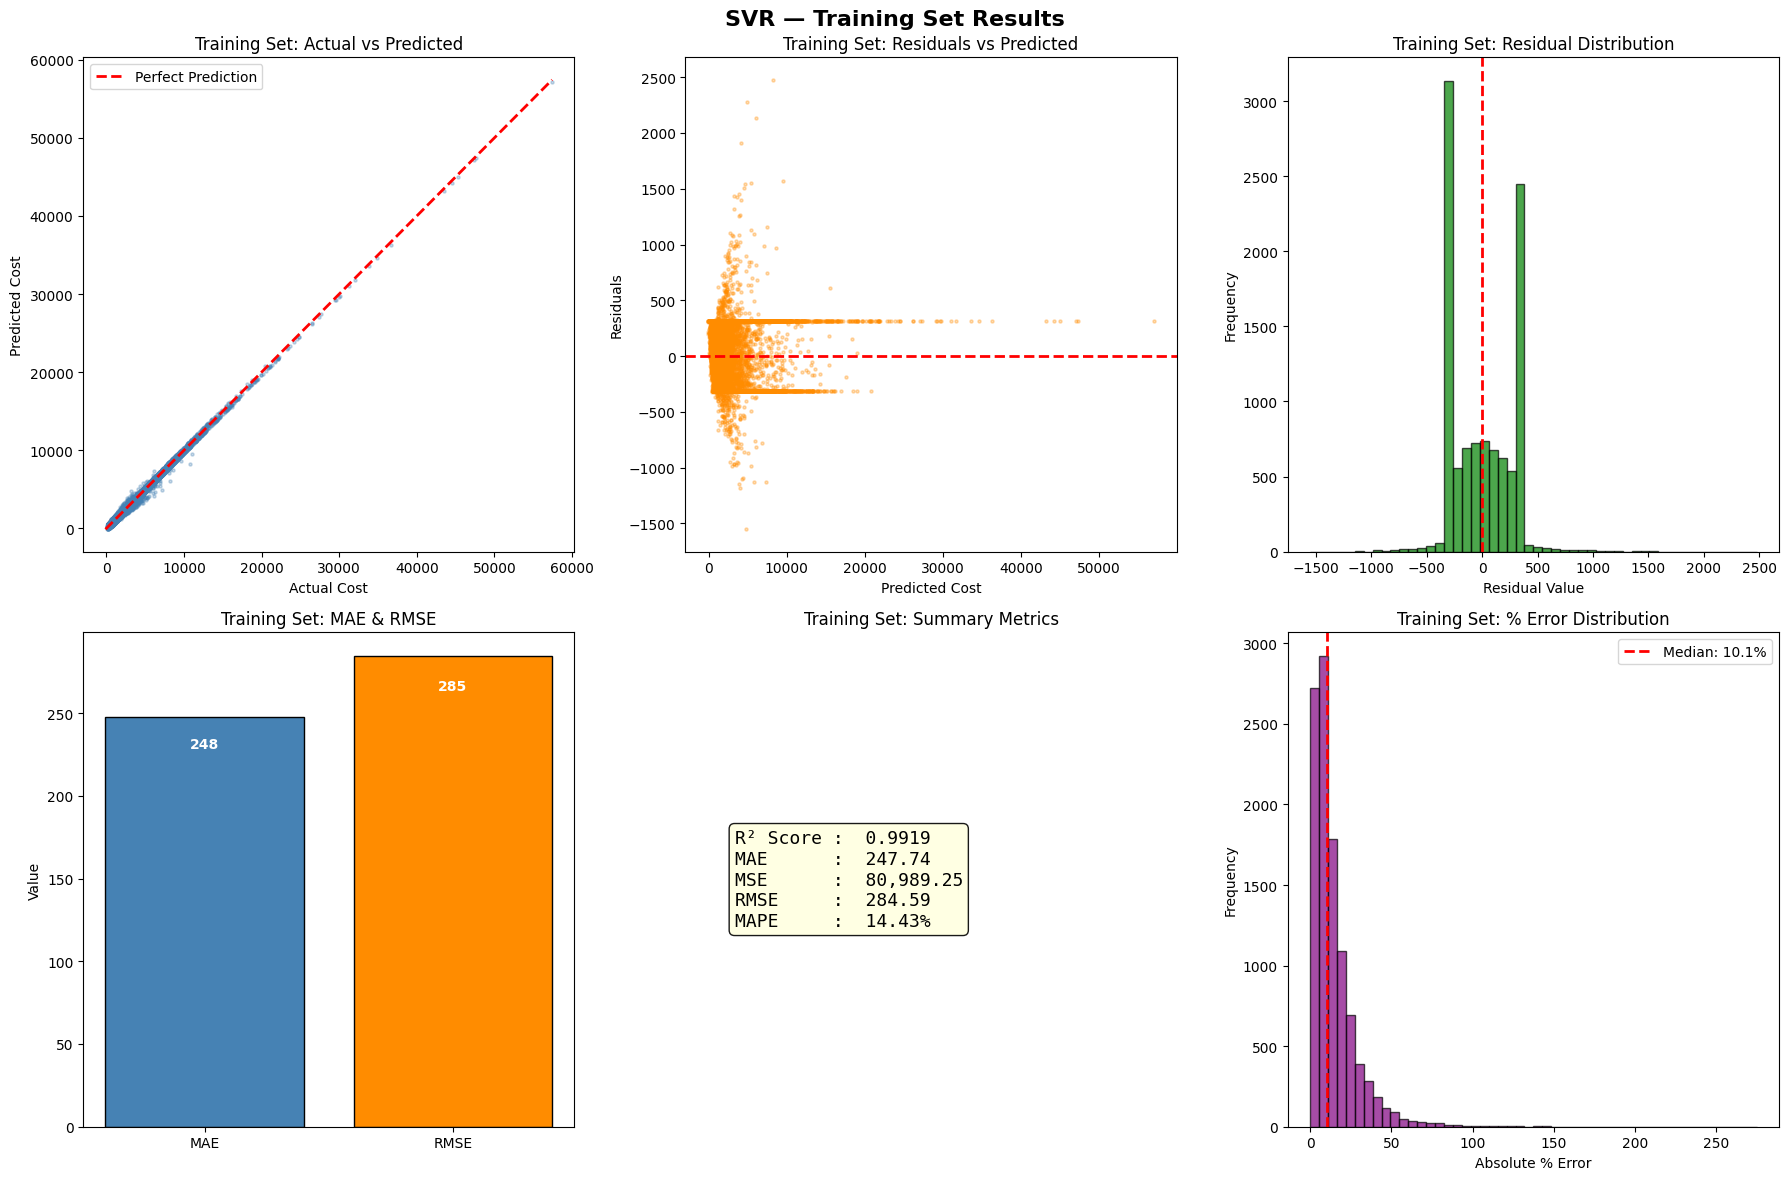

Saved: svr_training_results.png


In [10]:
# ──────────────────────────────────────────────────────────
# CELL 10: Training Set Evaluation & Visualizations
# ──────────────────────────────────────────────────────────

y_train_pred, train_metrics = evaluate_model(
    svr_model, X_train_scaled, y_train.values, scaler_y,
    label="TRAINING SET"
)

plot_results(
    y_train.values, y_train_pred, train_metrics,
    title_prefix="Training Set",
    save_prefix="svr_training"
)


  VALIDATION SET
  MAE:            586.73
  MSE:      1,042,026.01
  RMSE:         1,020.80
  R²:             0.8656
  MAPE:           24.61%


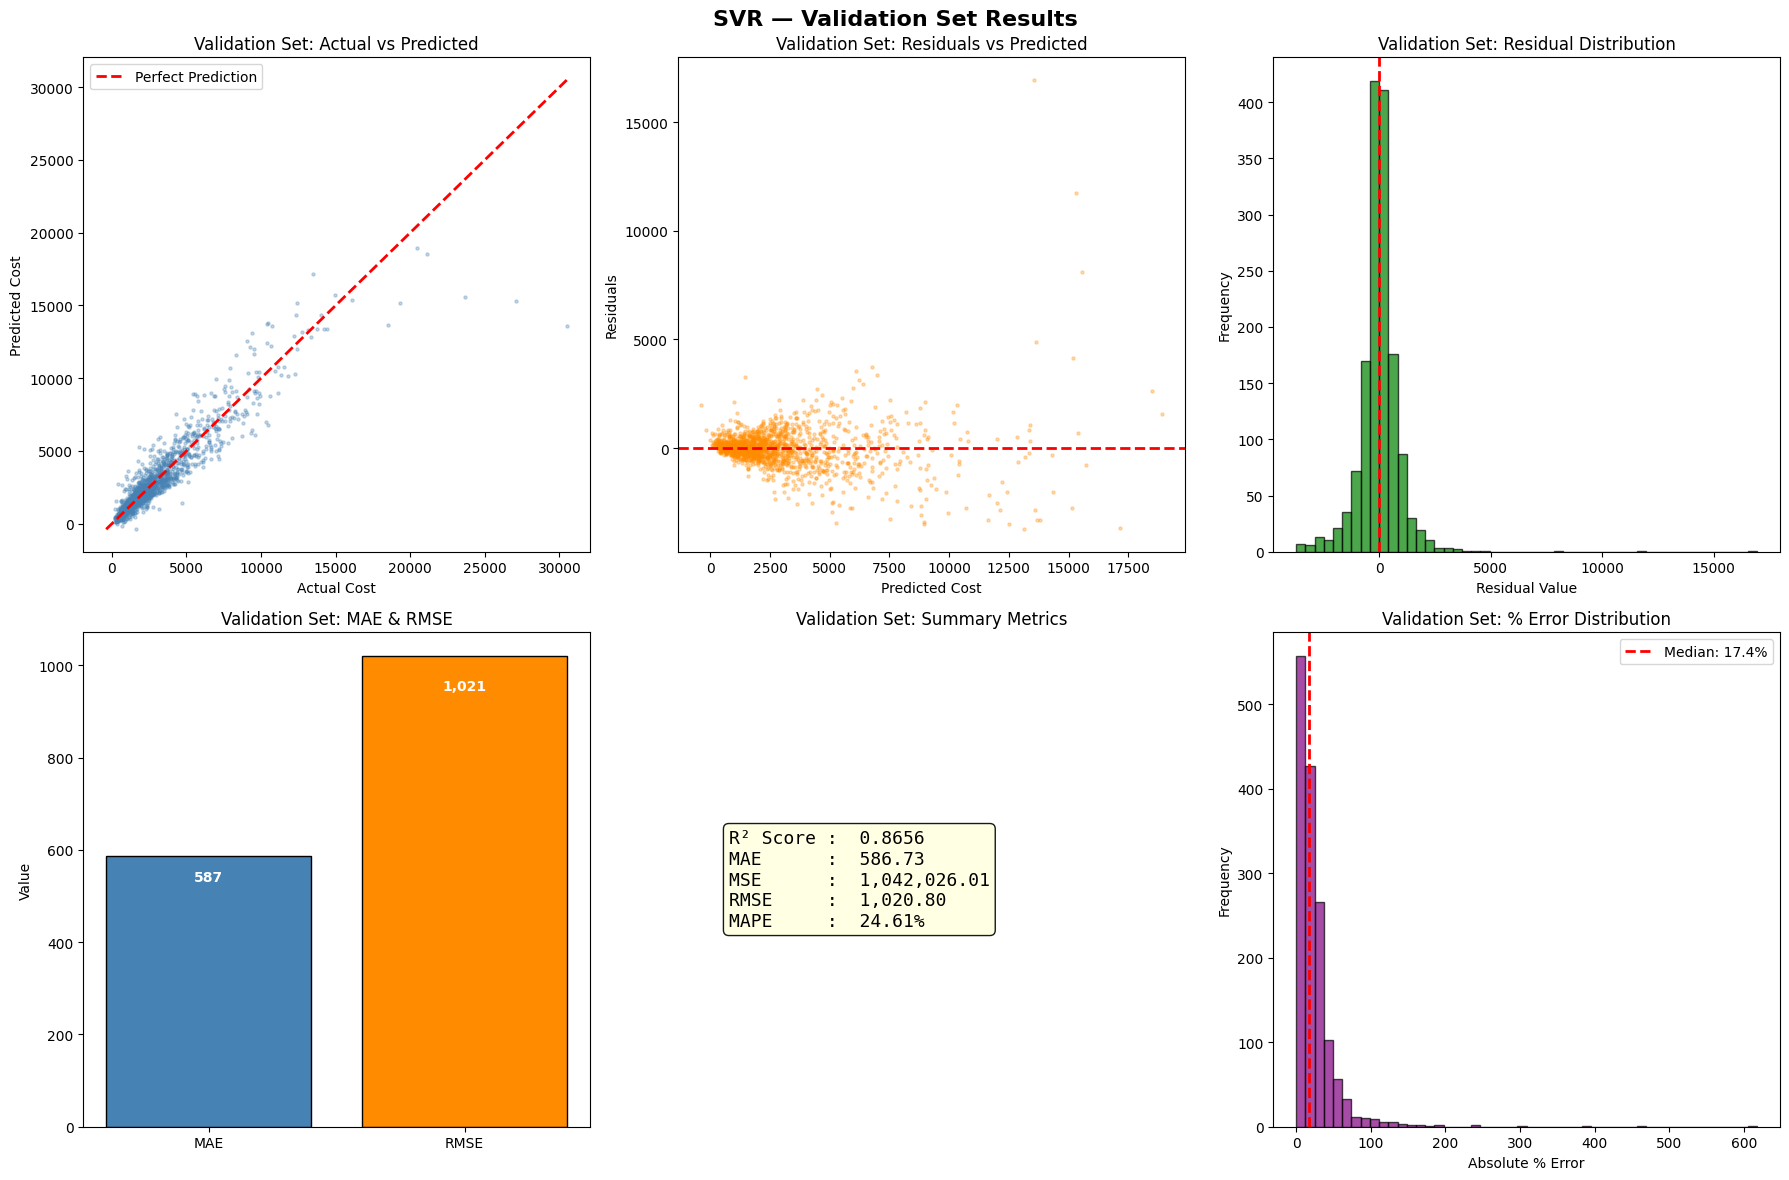

Saved: svr_validation_results.png


In [11]:
# ──────────────────────────────────────────────────────────
# CELL 11: Validation Set Evaluation & Visualizations
# ──────────────────────────────────────────────────────────

y_val_pred, val_metrics = evaluate_model(
    svr_model, X_val_scaled, y_val.values, scaler_y,
    label="VALIDATION SET"
)

plot_results(
    y_val.values, y_val_pred, val_metrics,
    title_prefix="Validation Set",
    save_prefix="svr_validation"
)

In [12]:
# ──────────────────────────────────────────────────────────
# CELL 12: Hyperparameter Tuning — RandomizedSearchCV
# (faster than GridSearchCV, runs on 5k sample)
# ──────────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

print("Running RandomizedSearchCV (10 iterations, 3-fold CV on 5k sample)...")
print("Estimated time: 5–15 minutes\n")

SAMPLE_N = 5000
X_tune = X_train_scaled[:SAMPLE_N]
y_tune = y_train_scaled[:SAMPLE_N]

param_dist = {
    'C':       loguniform(1, 1000),
    'epsilon': uniform(0.01, 0.5),
    'gamma':   ['scale', 'auto'],
}

random_search = RandomizedSearchCV(
    SVR(kernel='rbf', cache_size=1000),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

start_tune = time.time()
random_search.fit(X_tune, y_tune)
tune_time = time.time() - start_tune

print(f"\n✅ Tuning completed in {tune_time:.2f}s ({tune_time/60:.1f} min)")
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV R²:      {random_search.best_score_:.4f}")

# CV Results table
cv_results = pd.DataFrame(random_search.cv_results_)[
    ['param_C', 'param_epsilon', 'param_gamma',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')
print("\n=== CV Results (all iterations) ===")
print(cv_results.to_string(index=False))

Running RandomizedSearchCV (10 iterations, 3-fold CV on 5k sample)...
Estimated time: 5–15 minutes

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Tuning completed in 261.73s (4.4 min)
Best Parameters: {'C': np.float64(10.025956902289563), 'epsilon': np.float64(0.08143340896097039), 'gamma': 'scale'}
Best CV R²:      0.7555

=== CV Results (all iterations) ===
   param_C  param_epsilon param_gamma  mean_test_score  std_test_score  rank_test_score
 10.025957       0.081433       scale         0.755530        0.069265                1
 68.479201       0.079747        auto         0.751187        0.065073                2
218.309684       0.308425        auto         0.745997        0.059255                3
834.193029       0.126386        auto         0.742256        0.064336                4
  3.549879       0.162121        auto         0.738580        0.066610                5
  2.937538       0.039042        auto         0.731028        0.067839                6
 13.

In [13]:
# ──────────────────────────────────────────────────────────
# CELL 13: Retrain Best SVR on Full Training Data
# ──────────────────────────────────────────────────────────

best_params = random_search.best_params_
print(f"Retraining best SVR with: {best_params}")

best_svr = SVR(
    kernel='rbf',
    cache_size=2000,
    C=best_params['C'],
    epsilon=best_params['epsilon'],
    gamma=best_params['gamma']
)

start_retrain = time.time()
best_svr.fit(X_train_scaled, y_train_scaled)
retrain_time = time.time() - start_retrain

print(f"✅ Retrained in {retrain_time:.2f}s ({retrain_time/60:.1f} min)")
print(f"   Support vectors: {best_svr.n_support_[0]:,}")

# Save best model checkpoint
joblib.dump(best_svr, '/content/drive/MyDrive/svr_best_model.pkl')
print("✅ Best model saved to Drive")

Retraining best SVR with: {'C': np.float64(10.025956902289563), 'epsilon': np.float64(0.08143340896097039), 'gamma': 'scale'}
✅ Retrained in 26.41s (0.4 min)
   Support vectors: 5,799
✅ Best model saved to Drive



  TEST SET (Final)
  MAE:            552.49
  MSE:      2,149,600.22
  RMSE:         1,466.15
  R²:             0.7840
  MAPE:           22.20%


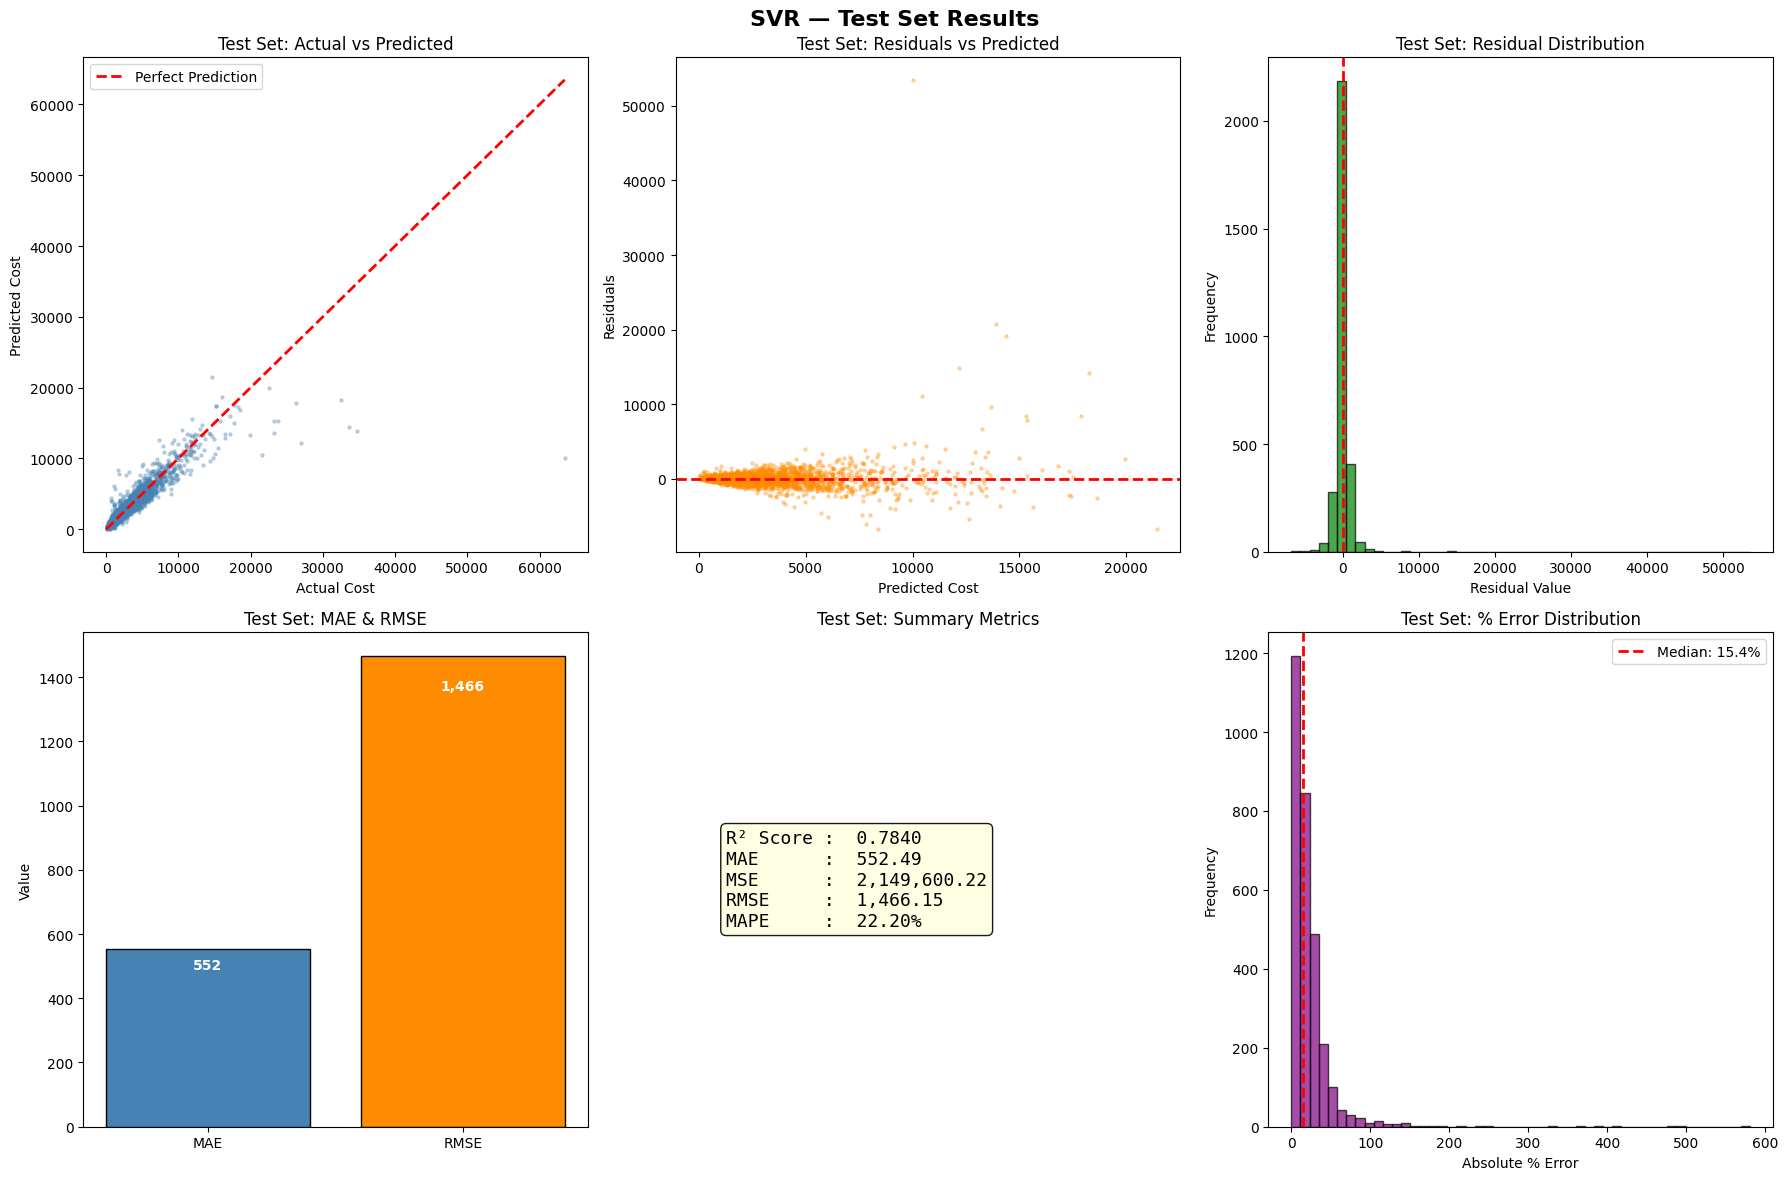

Saved: svr_test_results.png


In [14]:
# ──────────────────────────────────────────────────────────
# CELL 14: Final Test Set Evaluation & Visualizations
# ──────────────────────────────────────────────────────────

y_test_pred, test_metrics = evaluate_model(
    best_svr, X_test_scaled, y_test.values, scaler_y,
    label="TEST SET (Final)"
)

plot_results(
    y_test.values, y_test_pred, test_metrics,
    title_prefix="Test Set",
    save_prefix="svr_test"
)

Generating learning curve (5k subset, 3-fold CV)...
Estimated time: 5–10 minutes



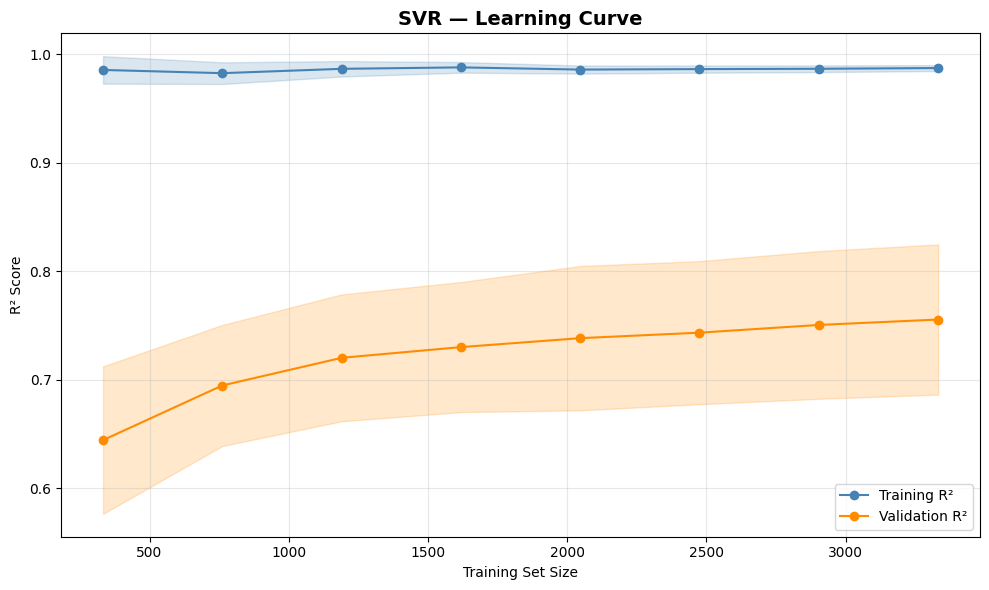

Saved: svr_learning_curve.png


In [15]:
# ──────────────────────────────────────────────────────────
# CELL 15: Learning Curve
# ──────────────────────────────────────────────────────────
from sklearn.model_selection import learning_curve

print("Generating learning curve (5k subset, 3-fold CV)...")
print("Estimated time: 5–10 minutes\n")

train_sizes, train_scores, val_scores = learning_curve(
    SVR(kernel='rbf',
        C=best_params['C'],
        epsilon=best_params['epsilon'],
        gamma=best_params['gamma'],
        cache_size=1000),
    X_train_scaled[:5000],
    y_train_scaled[:5000],
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training R²')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validation R²')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2, color='darkorange')
plt.title('SVR — Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svr_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: svr_learning_curve.png")

Computing permutation feature importance (5 repeats on test set)...
Estimated time: 3–8 minutes

Top 15 Features by Permutation Importance:
                    Feature  Importance      Std
            monthly_premium    0.261832 0.006225
             annual_premium    0.261425 0.006217
          total_claims_paid    0.171148 0.005844
           avg_claim_amount    0.036862 0.003329
              chronic_count    0.023450 0.000890
                 risk_score    0.022842 0.001262
days_hospitalized_last_3yrs    0.022711 0.001158
               claims_count    0.020524 0.002057
        had_major_procedure    0.015940 0.000589
         proc_surgery_count    0.012719 0.000276
 hospitalizations_last_3yrs    0.009746 0.000646
                        age    0.007902 0.000453
           visits_last_year    0.005618 0.001635
                   diabetes    0.005537 0.000450
               hypertension    0.005328 0.000614


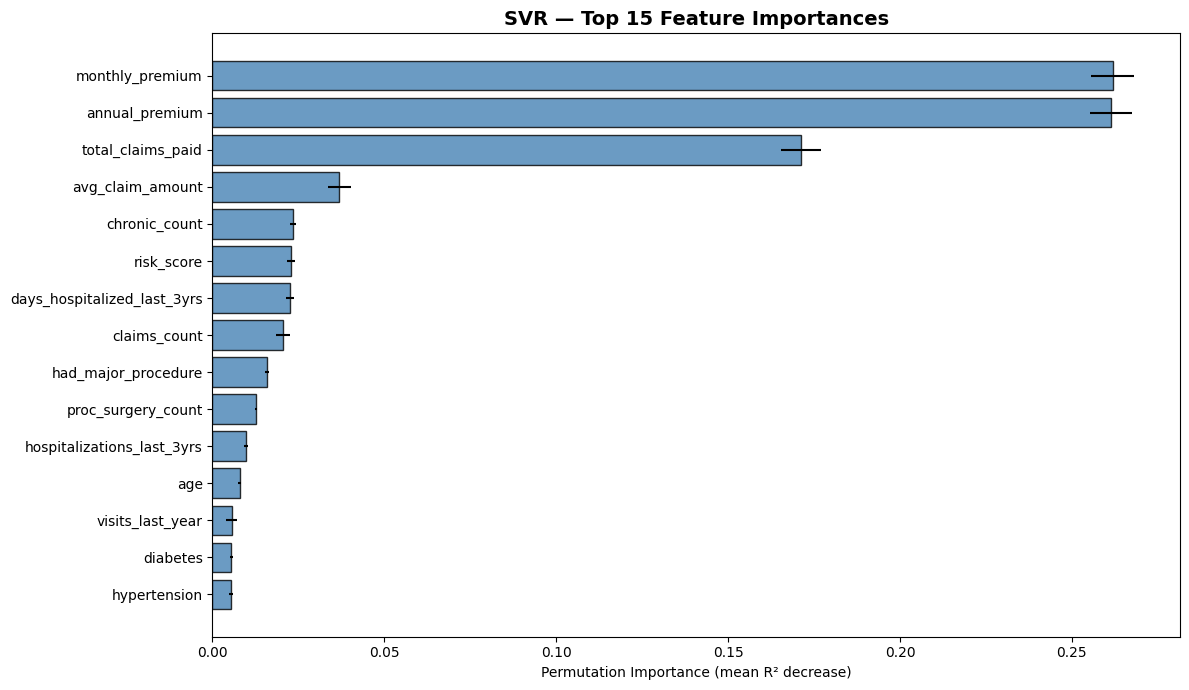

Saved: svr_feature_importance.png


In [16]:
# ──────────────────────────────────────────────────────────
# CELL 16: Permutation Feature Importance
# ──────────────────────────────────────────────────────────
from sklearn.inspection import permutation_importance

print("Computing permutation feature importance (5 repeats on test set)...")
print("Estimated time: 3–8 minutes\n")

y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

perm_result = permutation_importance(
    best_svr,
    X_test_scaled,
    y_test_scaled,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feat_importance = pd.DataFrame({
    'Feature':    selected_features,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std
}).sort_values('Importance', ascending=False)

print("Top 15 Features by Permutation Importance:")
print(feat_importance.head(15).to_string(index=False))

plt.figure(figsize=(12, 7))
top_fi = feat_importance.head(15)
plt.barh(top_fi['Feature'][::-1], top_fi['Importance'][::-1],
         xerr=top_fi['Std'][::-1],
         color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Permutation Importance (mean R² decrease)')
plt.title('SVR — Top 15 Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: svr_feature_importance.png")


  TRAINING (Best SVR)
  MAE:            242.72
  MSE:        131,817.88
  RMSE:           363.07
  R²:             0.9868
  MAPE:           13.00%

  VALIDATION (Best SVR)
  MAE:            535.00
  MSE:        925,596.98
  RMSE:           962.08
  R²:             0.8806
  MAPE:           21.80%

         FINAL PERFORMANCE SUMMARY — SVR MODEL
     Split        MAE        RMSE       R²     MAPE%
  Training 242.717924  363.067326 0.986823 13.002311
Validation 535.002049  962.079508 0.880645 21.798359
      Test 552.494487 1466.151498 0.784012 22.197519


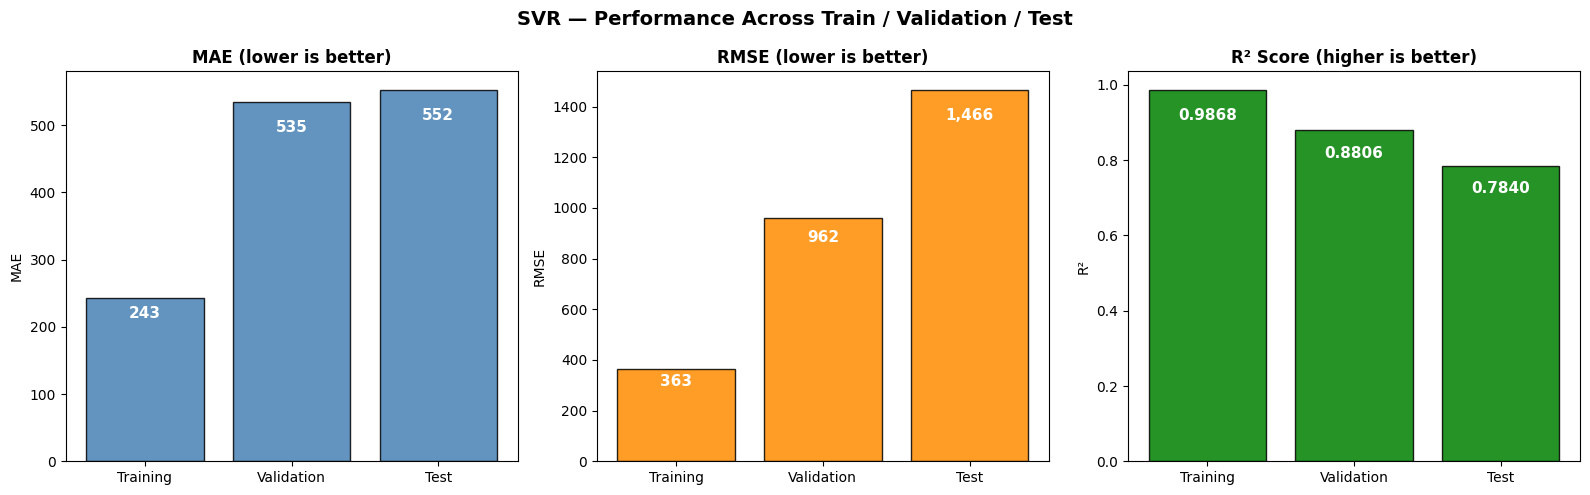

Saved: svr_split_comparison.png


In [17]:
# ──────────────────────────────────────────────────────────
# CELL 17: Final Summary — All Splits Comparison
# ──────────────────────────────────────────────────────────

# Recompute training & validation with best_svr
y_train_pred_best, train_metrics_best = evaluate_model(
    best_svr, X_train_scaled, y_train.values, scaler_y,
    label="TRAINING (Best SVR)"
)
y_val_pred_best, val_metrics_best = evaluate_model(
    best_svr, X_val_scaled, y_val.values, scaler_y,
    label="VALIDATION (Best SVR)"
)

# Summary DataFrame
summary = pd.DataFrame({
    'Split':  ['Training', 'Validation', 'Test'],
    'MAE':    [train_metrics_best['MAE'],  val_metrics_best['MAE'],  test_metrics['MAE']],
    'RMSE':   [train_metrics_best['RMSE'], val_metrics_best['RMSE'], test_metrics['RMSE']],
    'R²':     [train_metrics_best['R2'],   val_metrics_best['R2'],   test_metrics['R2']],
    'MAPE%':  [train_metrics_best['MAPE'], val_metrics_best['MAPE'], test_metrics['MAPE']],
})

print("\n" + "="*60)
print("         FINAL PERFORMANCE SUMMARY — SVR MODEL")
print("="*60)
print(summary.to_string(index=False))
print("="*60)

# Comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_cfg = [
    ('MAE',   'MAE (lower is better)',   'steelblue'),
    ('RMSE',  'RMSE (lower is better)',  'darkorange'),
    ('R²',    'R² Score (higher is better)', 'green'),
]

for ax, (metric, label, color) in zip(axes, metrics_cfg):
    bars = ax.bar(summary['Split'], summary[metric],
                  color=color, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, summary[metric]):
        fmt = f'{val:.4f}' if metric == 'R²' else f'{val:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 0.95,
                fmt, ha='center', va='top',
                color='white', fontweight='bold', fontsize=11)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(metric)

plt.suptitle('SVR — Performance Across Train / Validation / Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/svr_split_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: svr_split_comparison.png")

In [18]:
# ──────────────────────────────────────────────────────────
# CELL 18: Save All Artifacts to Drive
# ──────────────────────────────────────────────────────────

joblib.dump(best_svr,  '/content/drive/MyDrive/svr_final_model.pkl')
joblib.dump(scaler_X,  '/content/drive/MyDrive/svr_final_scaler_X.pkl')
joblib.dump(scaler_y,  '/content/drive/MyDrive/svr_final_scaler_y.pkl')
joblib.dump(selector,  '/content/drive/MyDrive/svr_final_selector.pkl')

summary.to_csv('/content/drive/MyDrive/svr_metrics_summary.csv', index=False)
feat_importance.to_csv('/content/drive/MyDrive/svr_feature_importance.csv', index=False)

print("✅ All artifacts saved to Google Drive:")
print("   svr_final_model.pkl")
print("   svr_final_scaler_X.pkl")
print("   svr_final_scaler_y.pkl")
print("   svr_final_selector.pkl")
print("   svr_metrics_summary.csv")
print("   svr_feature_importance.csv")
print("\n📊 Visualizations saved:")
print("   svr_target_distribution.png")
print("   svr_correlation_heatmap.png")
print("   svr_training_results.png")
print("   svr_validation_results.png")
print("   svr_test_results.png")
print("   svr_learning_curve.png")
print("   svr_feature_importance.png")
print("   svr_split_comparison.png")

✅ All artifacts saved to Google Drive:
   svr_final_model.pkl
   svr_final_scaler_X.pkl
   svr_final_scaler_y.pkl
   svr_final_selector.pkl
   svr_metrics_summary.csv
   svr_feature_importance.csv

📊 Visualizations saved:
   svr_target_distribution.png
   svr_correlation_heatmap.png
   svr_training_results.png
   svr_validation_results.png
   svr_test_results.png
   svr_learning_curve.png
   svr_feature_importance.png
   svr_split_comparison.png
